In [1]:

import jax.numpy as jnp

import sys

sys.path.append("../../siegel_analyses/scripts/")
sys.path.insert(1,'../scripts/')

import netrep_helpers as nh
import utils
import loader
import setup
import matplotlib.pyplot as plt

import seaborn as sns
%load_ext autoreload
%autoreload 2
import scipy.stats as sts
import numpy as np

import imp
imp.reload(setup)
imp.reload(loader)
imp.reload(utils)
import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

import matplotlib as mpl
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
mpl.rcParams.update(new_rc_params)

In [42]:
valid = [1, 2, 3, 4, 8, 10, 13, 14, 15, 16, 19, 21, 22, 23, 24, 25, 26, 29, 31, 32]


In [70]:
valid = [0, 1, 2, 4, 7, 8, 9, 10, 12, 13, 16, 17, 18, 19, 21, 22, 23, 25, 26, 27, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 48, 50, 51, 53, 55, 56, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 70, 72, 73, 74, 75, 77]

In [2]:
import pickle
with(open("1_fold_raw_behavior_all.pkl","rb")) as f:    
    cs_trials = pickle.load(f)


with open("1_folds_1_time_point_all.pkl","rb") as f:
    [params,train_data] = pickle.load(f)

## Andrews code

In [15]:
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import psychofit as psy
from netrep.metrics import LinearMetric
from scipy.ndimage import gaussian_filter

def deterministic_metrics_pair(pair,score,alpha=0.):
    Xi,Xj = pair

    metric = LinearMetric(alpha=alpha,
                          center_columns=True,
                          score_method=score)

    metric.fit(Xi,Xj)
    dist_neural = metric.score(Xi,Xj)
    return dist_neural


def distances_by_region(region, data, dist_behavioral, 
                        score, params, alpha=0,
                        smoothing=None, neuron_threshold=100):
    ys,cs = data
    
    if region == 'all':
        # If no region is specified, pull mice with at least neron_threshold
        # total neurons

        dist_behavioral_region = dist_behavioral

    else:
        # Pull all mice with at least neuron_threshold neurons in region
        usethese_region = np.array(
            [np.sum(data[n]['regions'] == region) > neuron_threshold 
            for n in range(len(data))])
    
        S = sum(usethese_region)    # Number of subjects
        print("Number of subjects in region ", region, ": ", S)
        if S == 0:
            return None, None, usethese_region

        # Subset behavioral distances by included mice
        dist_behavioral_region = \
            dist_behavioral[usethese_region,:][:,usethese_region]

    # Pull neural data
    spike_count = []

    max_n_neurons = 0

    for subj in data[usethese_region]:
        if region == 'all':
            
            # MODIFICATION
            # Select only neurons whose region is in region_list
            spikes_by_region = ys

        else:
            # Selects only neurons in region
            in_region = subj['regions'] == region
        
            n_neurons = np.sum(in_region)
            #sprint(f"Number of neurons in subject {subj}: ", n_neurons)

            if n_neurons > max_n_neurons: max_n_neurons = n_neurons

            # Pull spike counts by condition for selected neurons
            spikes_by_region = ys[:,:,in_region]

        # Pull the top neuron_threshold highest variance across conditions
        usethese_rate = \
            np.argsort(
                np.nanmean(spikes_by_region, axis=0).std(0))[-neuron_threshold:]
        spikes_by_region = np.nanmean(
            spikes_by_region[:,:,usethese_rate], axis=0
        )

        # Optionally, apply Gaussian filter with width sigma
        if smoothing is not None:
            
            # Width of firing rate bins in ms
            bin_width = (params['pre_time'] + 
                        params['post_time'])/params['n_bins'] * 1000
            
            spikes_by_region = \
                spikes_by_region.reshape(9, 
                                         params['n_bins'], 
                                         spikes_by_region.shape[1])
            
            spikes_by_region = gaussian_filter(spikes_by_region, 
                                               smoothing/bin_width, 
                                               axes=1)
            
            spikes_by_region = \
                spikes_by_region.reshape(9 * params['n_bins'],
                                         spikes_by_region.shape[2])
            
        spike_count.append(spikes_by_region)

    print("Max number of neurons across subjects: ", max_n_neurons)

    # Calculate neural distances for selected neurons
    dist_neural = np.array([deterministic_metrics_pair([spike_count[i], 
                                                spike_count[j]],
                                                score=score,
                                                alpha=alpha)
                    for i in range(S)
                    for j in range(S)]).reshape(S, S)
    
    return dist_behavioral_region, dist_neural, usethese_region


def fit_psychmetric(cs, dx=0.1):
    print(len(cs))
    # Fit psychometric curves to each session
    contrasts = np.array([-100, -25, -12.5, -6.25, 0., 6.25, 12.5, 25., 100.])
    psym_pars = np.empty((len(cs), 4)) # psychometric parameters
    
    percent_right = np.empty((len(cs), len(contrasts)))

    xx = np.arange(-100, 100, dx)
    fit_curve = np.zeros((len(cs), len(xx)))

    for ii, behavior in enumerate(cs):
        # Convert incorrect responses to 0 and average across conditions
        behavior[behavior == -1] = 0
        percent_correct = np.nanmean(behavior == 1, axis=0)

        # Convert to percent choose right
        percent_right[ii,:] = np.hstack((1-percent_correct[contrasts < 0],
                                percent_correct[contrasts >= 0]))

        n_trials = [np.sum(~np.isnan(x)) for x in behavior.T]

        # Format data for mle_fit_psycho
        # Row 1: conditions
        # Row 2: number of trials per condition
        # Row 3: percent left in each condition
        data = np.vstack((
            contrasts,
            n_trials,
            percent_right[ii,:]
        ))

        parmin = np.array([-20, -50, 0, 0])
        parmax = np.array([20, 50, 1, 1])
        psym_pars[ii,:], _ = \
            psy.mle_fit_psycho(data,
                               'erf_psycho_2gammas',
                               nfits=15,
                               parmin = parmin,
                               parmax = parmax)
        
        fit_curve[ii,:] = psy.erf_psycho_2gammas(psym_pars[ii,:], xx)

    return fit_curve, percent_right, psym_pars

def compute_behavioral_distance(data):

    _,cs = data
    cs = np.array(cs)

    fit_curve, percent_right, psycho_params = fit_psychmetric(cs)

    dist_behavioral = np.array(
        [np.sqrt(np.sum((fit_curve[i,:] - fit_curve[j,:])**2 * 0.1))
        for i in range(len(data))
        for j in range(len(data))]).reshape(len(data), len(data))

    return dist_behavioral, psycho_params, percent_right



In [9]:
ys, cs = train_data


In [18]:
cs

array([[ 0.95      ,  0.7       , -0.1       , -0.35      ,  0.3       ,
         0.55      ,  0.7       ,  0.75      ,  0.8       ],
       [ 0.96774194,  0.70967742,  0.38709677,  0.19354839,  0.29032258,
         0.41935484,  0.25806452,  0.70967742,  1.        ],
       [ 1.        ,  0.84375   ,  0.6875    ,  0.5       ,  0.1875    ,
         0.1875    ,  0.46875   ,  0.53125   ,  0.875     ],
       [ 1.        ,  1.        ,  0.92      ,  0.68      ,  0.28      ,
         0.52      ,  1.        ,  0.84      ,  1.        ],
       [ 1.        ,  0.9245283 ,  1.        ,  0.77358491,  0.05660377,
         0.16981132,  0.35849057,  0.54716981,  0.62264151],
       [ 0.97402597,  0.94805195,  0.58441558,  0.50649351,  0.35064935,
         0.16883117,  0.50649351,  0.81818182,  0.94805195],
       [ 0.74193548, -0.29032258, -0.80645161, -0.87096774,  0.09677419,
         0.74193548,  0.93548387,  0.87096774,  0.87096774],
       [ 1.        ,  0.93939394,  0.45454545,  0.51515152,  0

In [14]:
S = len(train_data)

bin_width = (params['pre_time'] +  params['post_time'])/params['n_bins'] * 1000

print('Number of bins = ', params['n_bins'])
print("Bin width = ", bin_width)

score = 'euclidean'

dist_behavioral, psycho_params,_ = compute_behavioral_distance(train_data)
dist_behavioral_region, dist_neural, _ = \
        distances_by_region('all', train_data, dist_behavioral,
                            score, params, smoothing=None, neuron_threshold=train_data)

dist_behavioral_flat = \
    dist_behavioral[np.triu_indices_from(dist_behavioral_region, 1)]
dist_neural_flat = \
        dist_neural[np.triu_indices_from(dist_neural, 1)]

r, p = sts.pearsonr(dist_behavioral_flat, dist_neural_flat)

plt.scatter(dist_behavioral_flat, dist_neural_flat)

plt.xlabel('behavior distance')
plt.ylabel('neural distance')

plt.title(f"all: r = {r:0.3f}, p = {p:0.3f}")
#plt.savefig(f"{figdir}all_behav_neur_corr.png")
#plt.savefig(f"{smoothing}_{neuron_threshold}_all_behav_neur_corr.png")

plt.show()

Number of bins =  10
Bin width =  40.0


IndexError: invalid index to scalar variable.

## Joaos code


In [19]:
def convert_to_rw_choices(cs_trials):
    choices = []
    for subject in cs_trials:
        left = subject[:,:4] == -1
        right = subject[:,5:] == 1
        both = np.column_stack([left.astype(int), right.astype(int)])
        choices.append(np.mean(both,0))
    return np.array(choices)

In [20]:
import numpy as np
import scipy.stats as sts
import tqdm
# import utils # Assuming utils is imported for dsd

def get_dists_full(data):
    """
    Computes distance matrices for the full dataset without CV splits.
    data: tuple (ys, cs) containing list of neural data and behavioral data for all subjects
    """
    ys, cs = data
    S = len(ys)

    # Compute neural distance matrix
    # Assumes utils.dsd can handle the list of arrays structure
    dist_neural = utils.dsd([
        [ys[i], ys[j]]
        for i in range(S) 
        for j in range(S)]
    ).reshape(S, S)

    dist_cc = np.zeros((S, S))

    # Compute behavioral distance matrix
    for i in range(S):
        for j in range(S):
            # Calculates mean absolute difference between behavioral vectors
            dist_cc[i, j] = np.mean(np.abs(cs[i] - cs[j]))

    return dist_neural, dist_cc, cs

def get_kneigh_decreasing(dist_neural, cs, W=2):
    """
    Compute correlation between subject behavior and average of K neighbors.
    Adapted to derive S from the matrix shape.
    """
    S = dist_neural.shape[0]
    avg_cc = np.array(cs)
    all_preds_top = []

    # Iterate K neighbors. Max neighbors = S-1 (everyone else).
    for K in range(W, S): 
        preds_top = []
        for subj in range(S):
            subj_idx = list(range(S))
            subj_idx.remove(subj)
            subj_idx = np.array(subj_idx)

            dists = dist_neural[subj][subj_idx] 
            sorted_idx = subj_idx[np.argsort(dists)]
            s_dists = np.sort(dists)

            # Extract the slice of K-W to K nearest neighbors
            top_k = avg_cc[sorted_idx[K-W:K]] 
            
            # Correlate subject behavior with average behavior of top K neighbors
            preds_top.append(sts.pearsonr(np.mean(top_k, 0), avg_cc[subj])[0])

        all_preds_top.append(preds_top)

    return np.array(all_preds_top)

In [23]:
import pickle
with(open("prep_andrew/modifications/raw_behavior_DG.pkl","rb")) as f:    
    cs_trials = pickle.load(f)


with open("prep_andrew/modifications/100_folds_1_time_point_DG.pkl","rb") as f:
    [params,train_data_folds,test_data_folds] = pickle.load(f)

In [ ]:

try: 
    dist_neural, dist_cc, cs = get_dists_full(train_data)
    
    S = dist_neural.shape[0]
    
    # Get upper triangle for correlation
    flat_dist_neural = dist_neural[np.triu_indices(S, 1)]
    flat_dist_cc = dist_cc[np.triu_indices(S, 1)]

    # Compute Ground Truth Correlation
    r_true, _ = sts.pearsonr(flat_dist_cc, flat_dist_neural)
    
    # Compute Neighbor Predictions
    preds_top = get_kneigh_decreasing(dist_neural, cs, W=2)

except np.linalg.LinAlgError:
    print("linalg error in distance calculation")

# 3. Compute Significance (Shuffles)
n_shuffles = 500
corrs_shuffle = []
flat_dist_cc_s = flat_dist_cc.copy()

print(f"Running {n_shuffles} shuffles for significance...")
for _ in tqdm.trange(n_shuffles):
    np.random.shuffle(flat_dist_cc_s)
    r_s, _ = sts.pearsonr(flat_dist_cc_s, flat_dist_neural)
    corrs_shuffle.append(r_s)

# Calculate Z-Score and P-value
z_score = (r_true - np.mean(corrs_shuffle)) / np.std(corrs_shuffle)
p_value = (np.sum(np.array(corrs_shuffle) >= r_true) + 1) / (n_shuffles + 1)

print(f"Correlation (r): {r_true:.4f}")
print(f"Z-Score: {z_score:.4f}")
print(f"P-Value: {p_value:.4f}")

2026-02-17 13:29:06,463	INFO worker.py:1998 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8266 
/Users/laurinemarty/miniconda3/envs/project/lib/python3.10/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Running 500 shuffles for significance...


100%|██████████| 500/500 [00:00<00:00, 8842.21it/s]

Correlation (r): -0.0353
Z-Score: -1.4932
P-Value: 0.9281


In [9]:
# data_corrs = np.array(all_c_corrs)[:,0]
data_corrs = np.array(all_c_corrs, dtype=object)[:,0]
dist_neural = all_dist_neural[np.argmax(data_corrs)].copy()
dist_cc = all_dist_cc[np.argmax(data_corrs)].copy()

# for plotting
dist_neural_ = dist_neural.copy()
dist_cc_ = dist_cc.copy()
dist_neural_[np.triu_indices(dist_neural.shape[0],0)] = np.nan
dist_cc_[np.tril_indices(dist_neural.shape[0],0)] = np.nan

In [10]:
dist_neural_.shape

(59, 59)

In [14]:
np.max(data_corrs)

np.float64(-0.03534430018307543)

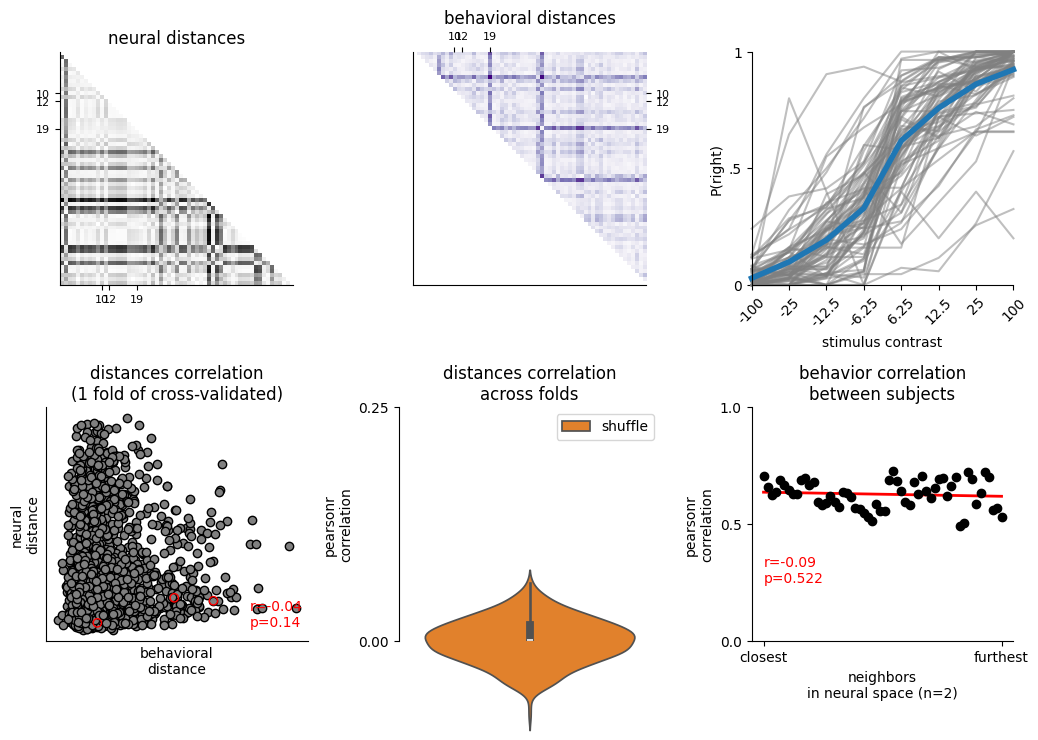

In [15]:
examples_idx= [10,12,19]
colors = np.array(sns.color_palette(None, S))

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7*1.5,5*1.5))

### DISTANCE MATRICES
axes = axes.flatten()
axes[0].set_title('neural distances')
axes[0].imshow(dist_neural_,cmap="Grays")
axes[0].set_xticks(examples_idx)
axes[0].set_yticks(examples_idx)
#cbar = plt.colorbar(axes[0].imshow(dist_neural_,cmap="Grays"),ax=axes[0],shrink=0.5,orientation="horizontal")


axes[1].set_title('behavioral distances')
axes[1].imshow(dist_cc_,cmap="Purples")
axes[1].set_xticks(examples_idx)
axes[1].set_yticks(examples_idx)
axes[1].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False,left=False,labelleft=False,right=True,labelright=True)
#plt.colorbar(axes[1].imshow(dist_cc_,cmap="Purples"),ax=axes[1],shrink=0.5,orientation="horizontal")

#change ticks fontsize
for ti,tick in enumerate(axes[0].get_xticklabels()):
    tick.set_fontsize(8)
    axes[0].get_yticklabels()[ti].set_fontsize(8)
    axes[1].get_xticklabels()[ti].set_fontsize(8)
    axes[1].get_yticklabels()[ti].set_fontsize(8)


### PSYCHOMETRIC CURVES
contrast = [-100.  ,  -25.  ,  -12.5 ,   -6.25,    0.  ,    6.25,   12.5 ,
         25.  ,  100.  ]

avg_cc = [np.mean(c==1,0) for c in cs_trials]

####
### previous version of example subjects
####
# for si,subj in enumerate(examples_idx):

#     axes[2].plot(range(9),avg_cc[subj],label="#%i" % subj,color=colors[subj],clip_on=False) 
#     axes[2].scatter(range(9),avg_cc[subj],edgecolors=colors[subj], s=50, facecolors='white', zorder=3,clip_on=False) 

# axes[2].set_ylabel("P(correct)")
# axes[2].set_xlabel("contrast")
# axes[2].legend(title="subject",ncols=2)
# axes[2].plot([4,4],[0,1],"--",color="gray")
# axes[2].plot([0,9],[0.5,0.5],"--",color="gray")
# axes[2].set_yticks([0,0.5,1],[0,'.5',1])
# axes[2].set_ylim(0,1)
# axes[2].set_xticks(range(len(contrast)),[-100,-25,-12.5,-6.25,0,6.25,12.5,25,100],rotation=45)

choices = convert_to_rw_choices(cs_trials)
axes[2].plot(choices.T, color='gray', alpha=0.5,clip_on=False)
axes[2].plot(np.mean(choices,0), lw=4,clip_on=False)   
axes[2].set_ylabel("P(right)")
axes[2].set_xlabel("stimulus contrast")
axes[2].set_xticks(range(len(contrast)-1),[-100,-25,-12.5,-6.25,6.25,12.5,25,100],rotation=45)
axes[2].set_yticks([0,0.5,1],[0,'.5',1])
axes[2].set_ylim(0,1)
axes[2].set_xlim(0,7)

# take upper triangle
flat_dist_neural = dist_neural[jnp.triu_indices(S,1)]
flat_dist_cc = dist_cc[jnp.triu_indices(S,1)]

r,p = sts.pearsonr(flat_dist_cc,flat_dist_neural)
axes[3].scatter( flat_dist_cc,flat_dist_neural,color="k",facecolors='gray')
axes[3].text(1,0.1,"r={:.2f}\np={:.2f}".format(r,p),color="red")
axes[3].set_xlabel("behavioral\ndistance")
axes[3].set_ylabel("neural\ndistance")
axes[3].set_xticks([])
axes[3].set_yticks([])
axes[3].set_title("distances correlation\n(1 fold of cross-validated)")
axes[3].scatter(dist_cc[examples_idx,:][:,examples_idx][np.triu_indices(len(examples_idx),1)].flatten(),
                dist_neural[examples_idx,:][:,examples_idx][np.triu_indices(len(examples_idx),1)].flatten(),facecolors='none', edgecolors='red',zorder=10)

####
### previous version of Z-scored correlations
####

# axes[4].hist(all_zscores,color="black",bins=20)
# axes[4].set_xlim(0,4)
# plt.xlim(0,4)
# axes[4].set_ylim(0,10)

# axes[4].set_yticks([0,5,10],['0','','10'])
# axes[4].set_xlabel("z-score")
# asymmetric_error = np.array([[np.mean(all_zscores) - np.percentile(all_zscores,2.5),np.percentile(all_zscores,97.5) - np.mean(all_zscores)]])
# axes[4].errorbar(np.mean(all_zscores),0.75,xerr=asymmetric_error.T,color="red",label="95% CI")
# axes[4].plot(np.mean(all_zscores),0.75,"o",color="red")
# axes[4].legend()

axes[4].set_title("distances correlation\nacross folds")
data_corrs = np.array(all_c_corrs, dtype=object)[:,0]
shuffle_corrs = np.array(all_c_corrs, dtype=object)[:,1].mean()

sns.violinplot(data_corrs,label="data",ax=axes[4])
sns.violinplot(shuffle_corrs,label="shuffle",ax=axes[4],clip_on=False)
axes[4].legend()
axes[4].set_ylabel("pearsonr\ncorrelation")
axes[4].set_yticks([0,0.25])
axes[4].set_ylim(0,0.25)
axes[4].set_xticks([])


_ids = list(range(S-1))*np.shape(all_preds_top)[0]

r=sts.linregress(_ids,np.nanmean(all_preds_top,2).reshape(-1))
num_sess = dist_neural_.shape[0]-1
#axes[5].plot(np.mean(all_preds_top,2).T,"k.",alpha=0.1,clip_on=False)
plt.errorbar(range(num_sess),np.nanmean(np.nanmean(all_preds_top,2),0),np.std(np.nanmean(all_preds_top,2),0),fmt='o',color='black',clip_on=False)
#axes[5].plot(np.mean(all_preds_top,2).mean(0),"r-",lw=2)
axes[5].set_title("behavior correlation\nbetween subjects")

axes[5].text(0,0.25,"r={:.2f}\np={:.3f}".format(r.rvalue,r.pvalue),color='r')  
axes[5].set_ylabel("pearsonr\ncorrelation")
axes[5].set_yticks([0,0.5,1])
#axes[5].set_xticks([0,(S-2)//2,S-2],["closest","[%i,%i]" % ((S-2)//2,(S-2)//2+1),"[%i,%i]" % (S-2,S-1)])
axes[5].set_xticks([0,S-2],["closest","furthest"])

axes[5].set_xlabel("neighbors\nin neural space (n=2)")
#axes[5].hlines(y=0.8, xmin=0, xmax=18, colors='black',lw=0.5)
axes[5].set_ylim(0,1)
#axes[5].text(9,.95,"*",color='black')
# plot regression line on top of the data using the slope and intercept
axes[5].plot(range(num_sess)*r.slope+r.intercept,"r-",lw=2)

fig.tight_layout()
sns.despine()
sns.despine(ax=axes[4],bottom=True)


#plt.savefig("../results_web_new/IBL_main_figure.svg",dpi=300)

In [50]:
np.nanmean(all_preds_top,2)

array([[0.49367392, 0.43772277, 0.44334894, ..., 0.38376308, 0.49755031,
        0.49877139],
       [0.29750446, 0.26863543, 0.41784003, ..., 0.51150065, 0.47009323,
        0.44871077],
       [0.41502829, 0.34926345, 0.39794707, ..., 0.43374335, 0.32216756,
        0.18124351],
       ...,
       [0.47457211, 0.47323499, 0.4675421 , ..., 0.50427901, 0.42193646,
        0.34162757],
       [0.36447829, 0.4019971 , 0.36150798, ..., 0.42324081, 0.42946678,
        0.39493265],
       [0.3114146 , 0.28915494, 0.31342513, ..., 0.3160016 , 0.4424357 ,
        0.411629  ]], shape=(49, 32))

In [16]:
np.percentile(data_corrs,[2.5,97.5])

array([np.float64(-0.03534430018307543), np.float64(-0.03534430018307543)],
      dtype=object)

In [48]:
sts.ttest_rel(np.mean(all_preds_top,0)[0],np.mean(all_preds_top,0)[-1])

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

<Figure size 70x375 with 0 Axes>

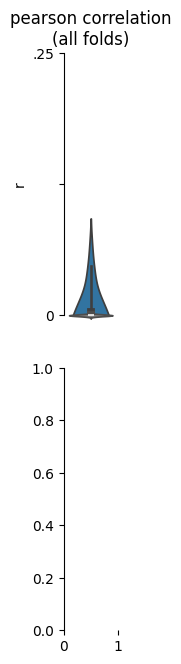

In [22]:


plt.figure(figsize=(7*1.5/15,5*1.5/2))

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7*1.5/15,5*1.5))
axes = axes.flatten()
axes[0].set_title("pearson correlation\n(all folds)")

sns.violinplot(data_corrs,label="data",ax=axes[0])
sns.violinplot(shuffle_corrs,label="shuffle",clip_on=False,color="gray",ax=axes[0])
axes[0].set_ylabel("r")
axes[0].set_yticks([0,0.25/2,0.25],[0,'','.25'])
axes[0].set_ylim(0,0.25)
axes[0].set_xticks([])
sns.despine(bottom=True)

#plt.savefig("../results_web_new/violinplot.svg",dpi=300)

In [11]:
from utils import filter_eids
pass_eids = filter_eids('../data_new/2022_Q2_IBL_et_al_RepeatedSite/QC.json')